<a href="https://colab.research.google.com/github/aalonsomt/Challenge-TelecomX_2/blob/main/TelecomX_LATAM%20(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [1]:
import requests


In [2]:
import pandas as pd

In [3]:
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/refs/heads/main/TelecomX_Data.json'
response = requests.get(url)
data = response.json()
df = pd.DataFrame(data)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [4]:
df = pd.json_normalize(data)
df

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


#🔧 Transformación

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [6]:
# Verificar valores únicos
for col in df.columns:
  print(f'{col}: {df[col].nunique()}')
  if df[col].nunique() < 50:
    print(df[col].unique())
    print('-' * 50)

customerID: 7267
Churn: 3
['No' 'Yes' '']
--------------------------------------------------
customer.gender: 2
['Female' 'Male']
--------------------------------------------------
customer.SeniorCitizen: 2
[0 1]
--------------------------------------------------
customer.Partner: 2
['Yes' 'No']
--------------------------------------------------
customer.Dependents: 2
['Yes' 'No']
--------------------------------------------------
customer.tenure: 73
phone.PhoneService: 2
['Yes' 'No']
--------------------------------------------------
phone.MultipleLines: 3
['No' 'Yes' 'No phone service']
--------------------------------------------------
internet.InternetService: 3
['DSL' 'Fiber optic' 'No']
--------------------------------------------------
internet.OnlineSecurity: 3
['No' 'Yes' 'No internet service']
--------------------------------------------------
internet.OnlineBackup: 3
['Yes' 'No' 'No internet service']
--------------------------------------------------
internet.DeviceProtecti

In [7]:
# Verifico valores duplicados
print('Número de duplicados', df.duplicated().sum())

Número de duplicados 0


In [8]:
# Reviso valores nulos
print('Número de valores nulos \n', df.isnull().sum())

Número de valores nulos 
 customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64


In [9]:
# Valores en blanco

df.apply(lambda x: x.astype(str).str.strip() == '').sum()

,0
customerID,0
Churn,224
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [10]:
# Transformación
# Columna 'account.Charges.Total' a tipo Float

df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')


In [11]:
df= df[df['Churn'].str.strip() != '']
print("Número de filas después de eliminar las vacías en 'Churn':", len(df))

Número de filas después de eliminar las vacías en 'Churn': 7043


In [12]:
# Verifica vacío o en blanco
df.apply(lambda x: x.astype(str).str.strip() == '').sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [13]:
print('Número de nulos \n', df.isnull().sum())

Número de nulos 
 customerID                    0
Churn                         0
customer.gender               0
customer.SeniorCitizen        0
customer.Partner              0
customer.Dependents           0
customer.tenure               0
phone.PhoneService            0
phone.MultipleLines           0
internet.InternetService      0
internet.OnlineSecurity       0
internet.OnlineBackup         0
internet.DeviceProtection     0
internet.TechSupport          0
internet.StreamingTV          0
internet.StreamingMovies      0
account.Contract              0
account.PaperlessBilling      0
account.PaymentMethod         0
account.Charges.Monthly       0
account.Charges.Total        11
dtype: int64


In [14]:
df = df.dropna(subset=['account.Charges.Total'])
df

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.90
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [15]:
df.tail()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.90
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65
7266,9995-HOTOH,No,Male,0,Yes,Yes,63,No,No phone service,DSL,...,Yes,Yes,No,Yes,Yes,Two year,No,Electronic check,59.00,3707.60


In [16]:
df.sample(5)

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
894,1262-OPMFY,Yes,Female,0,Yes,No,9,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Bank transfer (automatic),75.75,655.90
3059,4257-GAESD,No,Female,0,No,No,6,No,No phone service,DSL,...,No,No,No,Yes,Yes,Month-to-month,No,Credit card (automatic),45.00,298.70
7001,9639-BUJXT,No,Male,0,No,No,63,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.50,1328.15
822,1167-OYZJF,No,Female,1,Yes,No,67,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.05,1263.05
5568,7613-LLQFO,Yes,Male,0,No,No,12,Yes,Yes,Fiber optic,...,No,No,No,Yes,No,Month-to-month,Yes,Electronic check,84.45,1059.55


In [17]:
df.to_csv('TelecomX_Data.csv', index=False)

#📊 Carga y análisis

In [18]:
# Análisis Descriptivo
df.describe()

,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


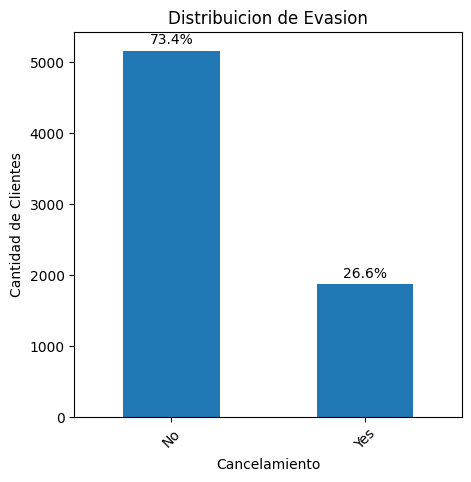

In [19]:
# Distribución de la Evación
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
churn_counts = df['Churn'].value_counts()
churn_percentages = (churn_counts / len(df)) * 100

ax = churn_counts.plot(kind='bar')
plt.title('Distribuicion de Evasion')
plt.xlabel('Cancelamiento')
plt.ylabel('Cantidad de Clientes')
plt.xticks(rotation=45)

for i, percentage in enumerate(churn_percentages):
    ax.text(i, churn_counts.iloc[i] + 50, f'{percentage:.1f}%', ha='center', va='bottom')

plt.show()

In [20]:
import plotly.express as px



In [21]:
px.histogram(df, x='customer.gender', text_auto=True, color='Churn', barmode='group', color_discrete_sequence=['green', 'orange'])

In [22]:
px.histogram(df, x='customer.tenure', text_auto=True, color='Churn', barmode='group', color_discrete_sequence=['green','orange'])

In [23]:
px.histogram(    df, x='account.Contract', text_auto=True, color='Churn', barmode='group', color_discrete_sequence=['green', 'orange'])

In [24]:
px.histogram( df, x='internet.InternetService', text_auto=True, color='Churn', barmode='group', color_discrete_map={ 'No': 'green', 'Yes': 'orange' })

In [25]:
fig = px.histogram( df, x='account.PaymentMethod', text_auto=True, color='Churn', barmode='group', color_discrete_map={ 'No': 'green', 'Yes': 'orange' })

fig.update_xaxes(tickangle=-45)

fig.show()

#📄Informe final

## 1. Introducción

El objetivo de este análisis es identificar patrones y factores asociados con la evasión de clientes en TelecomX, utilizando técnicas de análisis exploratorio de datos. A partir de esta información, se busca generar insights que permitan mejorar las estrategias de retención de clientes.




## 2. Limpieza y Tratamiento de Datos



Para preparar los datos para el análisis se realizaron varias etapas de procesamiento:

**Importación de datos**

Los datos fueron importados en un DataFrame utilizando la biblioteca Pandas.

Revisión inicial del dataset

Se analizaron:

- estructura del dataset
- tipos de datos
- cantidad de registros
- valores faltantes

**Tratamiento realizado**

Durante la limpieza de datos se realizaron acciones como:

- Conversión de tipos de datos para variables numéricas.
- Revisión de valores nulos o inconsistentes.
- Estandarización de nombres de columnas.
- Selección de variables relevantes para el análisis.

Este proceso permitió asegurar que el dataset estuviera limpio, consistente y listo para el análisis exploratorio.

## 3. Análisis Exploratorio de Datos (EDA)



Durante el análisis exploratorio se analizaron diferentes variables para identificar posibles factores relacionados con la evasión de clientes.

**Churn por género**

El análisis por género permite observar si existe alguna diferencia significativa entre hombres y mujeres en la tasa de cancelación.

En general, el género no parece ser un factor determinante en la evasión de clientes.

**Churn por tiempo de permanencia (Tenure)**

El tiempo que un cliente permanece en la empresa tiene una fuerte relación con la evasión.

Se observó que:

Los clientes con menos tiempo en la empresa presentan mayor churn.

Los clientes con mayor antigüedad tienden a permanecer más tiempo.

Esto sugiere que los primeros meses del cliente son críticos para su fidelización.

**Churn por tipo de contrato**

El análisis muestra una diferencia clara según el tipo de contrato:

Contratos mensuales (Month-to-Month) presentan mayor tasa de churn.

Contratos de uno o dos años presentan menor tasa de cancelación.

Esto ocurre porque los contratos largos generan mayor compromiso del cliente con la empresa.

**Churn por tipo de servicio de internet**

El análisis del servicio de internet muestra que algunos tipos de servicio presentan mayor tasa de evasión que otros.

Esto puede estar relacionado con:

calidad del servicio

expectativas del cliente

precio del plan

**Churn por método de pago**

El método de pago también puede influir en el comportamiento del cliente.

Por ejemplo:

métodos de pago manuales pueden estar asociados a mayor churn

pagos automáticos suelen indicar mayor estabilidad del cliente

---



## 4. Conclusiones e Insights



A partir del análisis exploratorio se identificaron varios factores asociados con la evasión de clientes:

- Factores asociados a mayor churn
- Clientes con contratos mensuales
- Clientes con poco tiempo en la empresa
- Algunos tipos específicos de servicio de internet
- Métodos de pago no automáticos
- Factores asociados a menor churn
- Clientes con contratos de largo plazo
- Clientes con mayor antigüedad
- Clientes con pagos automáticos

Estos hallazgos sugieren que la permanencia y el tipo de contrato son factores clave en la retención de clientes.

## 5. Recomendaciones

Con base en el análisis realizado, se sugieren las siguientes estrategias para reducir la evasión de clientes:

### a. Incentivar contratos de largo plazo

Ofrecer descuentos o beneficios para clientes que elijan contratos anuales o bianuales.

### b. Programas de retención para clientes nuevos

Los primeros meses del cliente son críticos. Se podrían implementar: promociones iniciales, seguimiento de satisfacción y soporte prioritario


### c. Incentivar pagos automáticos

Promover métodos de pago automáticos mediante: descuentos, recompensas y facturación simplificada


### d. Mejorar calidad de servicio

Analizar los servicios que presentan mayor churn y evaluar posibles mejoras.



---



In [27]:
df.to_csv("datos_tratados.csv", index=False)

In [28]:
 df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7032 non-null   object 
 1   Churn                      7032 non-null   object 
 2   customer.gender            7032 non-null   object 
 3   customer.SeniorCitizen     7032 non-null   int64  
 4   customer.Partner           7032 non-null   object 
 5   customer.Dependents        7032 non-null   object 
 6   customer.tenure            7032 non-null   int64  
 7   phone.PhoneService         7032 non-null   object 
 8   phone.MultipleLines        7032 non-null   object 
 9   internet.InternetService   7032 non-null   object 
 10  internet.OnlineSecurity    7032 non-null   object 
 11  internet.OnlineBackup      7032 non-null   object 
 12  internet.DeviceProtection  7032 non-null   object 
 13  internet.TechSupport       7032 non-null   object 
 1